# Clase 1 · Fundamentos de la ciencia de datos

**Módulo 1: Introducción y fundamentos estadísticos** · Diplomado en Ciencia de Datos Aplicada · UTFSM

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daniopitz/diplomado-cdd/blob/main/01_intro_ecosistema_colab.ipynb)

Esta es la versión para **Google Colab**: las librerías ya vienen instaladas, así que no hay nada que configurar. Si prefiere trabajar en su propio computador, use el notebook `01_intro_ecosistema.ipynb` del repositorio, con el entorno de la guía de instalación.

En esta primera sesión el objetivo es modesto y concreto: comprobar que el entorno funciona y recorrer una vez el circuito completo datos → tabla → gráfico con datos reales, los de la Encuesta Origen Destino de Santiago 2012 (EOD). Cada pieza se estudia en profundidad en las próximas clases.

## 1. Verificación del entorno

Si esta celda corre sin errores y muestra las versiones, está todo en orden.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("NumPy      ", np.__version__)
print("Pandas     ", pd.__version__)
print("Matplotlib ", matplotlib.__version__)

NumPy       2.5.2
Pandas      3.0.5
Matplotlib  3.11.1


## 2. NumPy: cálculo sobre arreglos completos

NumPy aporta el arreglo (`array`): una colección de números sobre la que las operaciones se aplican completas, sin escribir ciclos. A eso se le llama vectorización, y es la base de todo el ecosistema: Pandas y Matplotlib trabajan sobre arreglos de NumPy.

Estos cinco valores son duraciones de viaje, en minutos:

In [2]:
tiempos = np.array([70, 105, 90, 25, 40])

print("Media:  ", tiempos.mean(), "minutos")
print("Máximo: ", tiempos.max(), "minutos")
print("En horas:", tiempos / 60)

Media:   66.0 minutos
Máximo:  105 minutos
En horas: [1.16666667 1.75       1.5        0.41666667 0.66666667]


La división `tiempos / 60` se aplicó a los cinco valores de una vez. Con cinco números da lo mismo; con los cientos de miles de filas de una encuesta, la diferencia de velocidad y de claridad del código es considerable.

## 3. Pandas: abrir una tabla real

Pandas aporta el `DataFrame`: una tabla con columnas etiquetadas, cada una de su propio tipo. Vamos a abrir la tabla de viajes de la EOD 2012 directo desde una URL.

Dos detalles del archivo: los campos van separados por punto y coma (`sep=";"`) y los decimales usan coma (`decimal=","`). El archivo pesa unos 15 MB, así que la descarga puede tomar algunos segundos.

In [3]:
URL = (
    "https://raw.githubusercontent.com/daniopitz/cienciadatos/"
    "main/datos/eod_stgo/viajes.csv"
)
viajes = pd.read_csv(URL, sep=";", decimal=",", low_memory=False)

viajes.shape

(113591, 35)

113.591 filas: una por viaje registrado. Las tres miradas iniciales a cualquier tabla nueva son `shape` (dimensiones), `head` (primeras filas) e `info` (columnas y tipos).

In [4]:
viajes[["Hogar", "Persona", "ComunaOrigen", "ComunaDestino", "TiempoViaje"]].head()

,Hogar,Persona,ComunaOrigen,ComunaDestino,TiempoViaje
0,173431,17343102,94.0,94.0,70.0
1,173441,17344101,94.0,71.0,105.0
2,173441,17344101,71.0,94.0,90.0
3,173441,17344103,94.0,91.0,55.0
4,173441,17344103,91.0,94.0,150.0


In [5]:
viajes.info(max_cols=15)

<class 'pandas.DataFrame'>
RangeIndex: 113591 entries, 0 to 113590
Columns: 35 entries, Hogar to CodigoTiempo
dtypes: float64(22), int64(9), str(4)
memory usage: 30.3 MB


Ojo con `ComunaOrigen`: sus valores son números (94, 71, 13...), pero la variable es nominal: cada número es un código de comuna que se resuelve contra una tabla de parámetros. Promediar códigos no significa nada; contar viajes por comuna, sí. El tipo de la variable define qué análisis es válido.

## 4. Matplotlib: el primer gráfico

Cerramos el circuito: de la tabla a un gráfico. `TiempoViaje` está en minutos y `FactorLaboralNormal` es el factor de expansión de cada viaje (cuántos viajes de la ciudad representa ese viaje encuestado; los factores se trabajan en detalle en las clases 2 y 3).

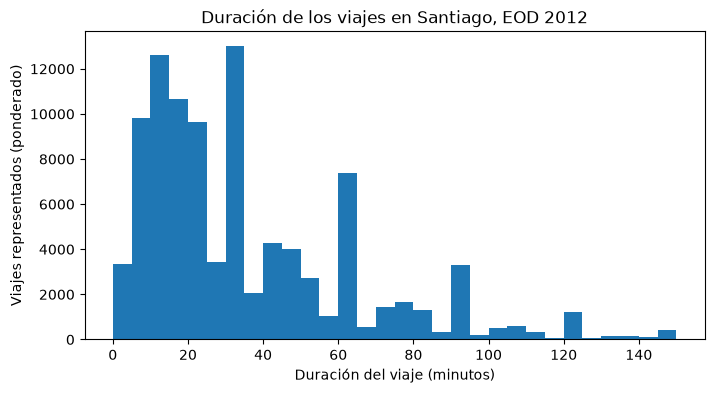

In [6]:
datos = viajes.dropna(subset=["TiempoViaje", "FactorLaboralNormal"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(datos["TiempoViaje"], bins=30, range=(0, 150),
        weights=datos["FactorLaboralNormal"])
ax.set_xlabel("Duración del viaje (minutos)")
ax.set_ylabel("Viajes representados (ponderado)")
ax.set_title("Duración de los viajes en Santiago, EOD 2012")
plt.show()

Dos cosas para mirar en el histograma: la cola larga hacia la derecha (pocos viajes muy largos) y los peaks en los múltiplos de media hora, porque las personas declaran duraciones redondeadas. En la clase 2 pondremos números a esta forma: media, mediana, dispersión.

## 5. Ejercicio

La misma encuesta tiene una tabla de personas, en
`https://raw.githubusercontent.com/daniopitz/cienciadatos/main/datos/eod_stgo/personas.csv`
(mismo separador y mismo decimal).

1. Ábrala con `pd.read_csv` y revise `shape`, `head` e `info`.
2. Identifique dos columnas numéricas y dos que, aunque contengan números, sean en realidad variables nominales (códigos).
3. Anote una pregunta sobre los viajes de Santiago que le gustaría responder con estas dos tablas.

In [7]:
# Su solución


---

**Próxima clase (jueves 27):** estadística descriptiva, trabajando sobre estas mismas tablas. Traiga el entorno funcionando; si algo falló hoy, revise la sección de problemas frecuentes de la guía de instalación o escríbanos.